# Principal Component Analysis — Handwritten Digits

**Algorithm:** `ml_toolkit.unsupervised.PCA`  
**Dataset:** UCI Digits 8×8  
**Task type:** Dimensionality reduction (no labels used to fit; labels used only for visualization)

---

PCA finds the directions of maximum variance in the data. On 64-dimensional digits, we ask two questions: (1) how few dimensions do we need to keep most of the variance? (2) when we project to two dimensions for plotting, do the digit classes — which PCA never saw — separate? The answer to (2) is the cleanest visual demonstration of why "unsupervised" doesn't mean "useless".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits

from ml_toolkit.unsupervised import PCA
from ml_toolkit.utils import StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

Same dataset as the MLP notebook: 1797 hand-written digits, each an 8×8 image flattened to a 64-d vector. PCA does not use the labels; we keep them aside only to color the projection plot at the end.

In [2]:
data = load_digits()
X = data.data
y = data.target
print(f'X shape: {X.shape}')

X shape: (1797, 64)


## 2. EDA: where does the variance live?

Pixels at the corners of an 8×8 digit image are almost always 0 — they are outside any digit shape — so they have near-zero variance and contribute nothing. The pixels in the middle do most of the work. PCA will discover this without being told.

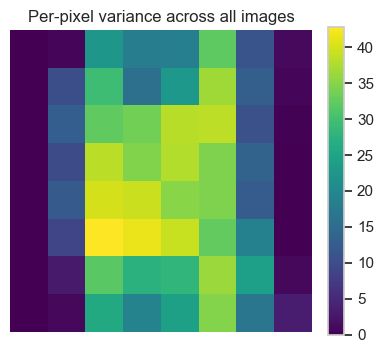

In [3]:
pixel_var = X.var(axis=0).reshape(8, 8)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(pixel_var, cmap='viridis')
ax.set_title('Per-pixel variance across all images')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Hypothesis

**Task:** dimensionality reduction.  
**Hypothesis:** ~80% of the variance should be captured by ~10 components, and ~95% by ~30 components — typical of pixel data, where neighbouring pixels are correlated. A 2-D projection should already separate digit classes coarsely, with confusable pairs (1↔7, 4↔9, 3↔8) overlapping.

## 4. Preprocessing

PCA is sensitive to feature scales — the direction of maximum variance is dominated by the highest-variance feature, which on raw pixel data means the brightest spots. Standardizing puts every pixel on the same footing. (For some image applications you'd skip this; for digit recognition where each pixel is a separate semantic unit, scaling is the more common choice.)

In [4]:
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

## 5. Model fitting & 6. Evaluation

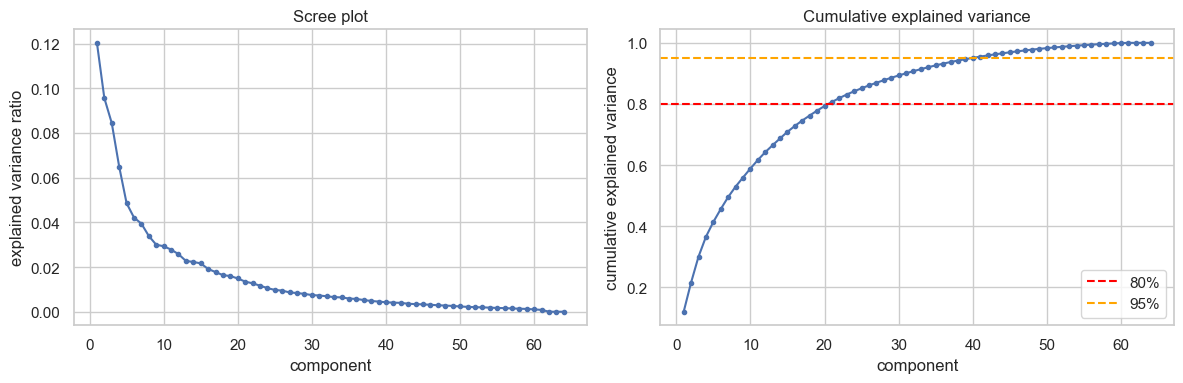

Components needed for 80%: 21
Components needed for 95%: 40


In [5]:
pca = PCA(n_components=64)  # all of them
pca.fit(X_s)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(evr) + 1), evr, marker='o', markersize=3)
axes[0].set_xlabel('component'); axes[0].set_ylabel('explained variance ratio')
axes[0].set_title('Scree plot')

axes[1].plot(np.arange(1, len(cum) + 1), cum, marker='o', markersize=3)
axes[1].axhline(0.8, color='red', linestyle='--', label='80%')
axes[1].axhline(0.95, color='orange', linestyle='--', label='95%')
axes[1].set_xlabel('component'); axes[1].set_ylabel('cumulative explained variance')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()
plt.tight_layout(); plt.show()

k80 = int(np.searchsorted(cum, 0.80) + 1)
k95 = int(np.searchsorted(cum, 0.95) + 1)
print(f'Components needed for 80%: {k80}')
print(f'Components needed for 95%: {k95}')

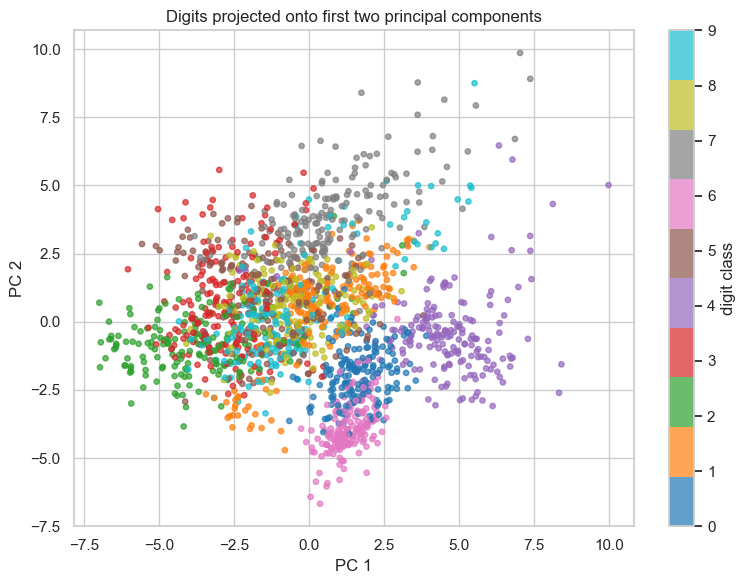

In [6]:
# Project to 2D and color by label
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_s)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.7, s=15)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Digits projected onto first two principal components')
plt.colorbar(scatter, ax=ax, label='digit class')
plt.tight_layout(); plt.show()

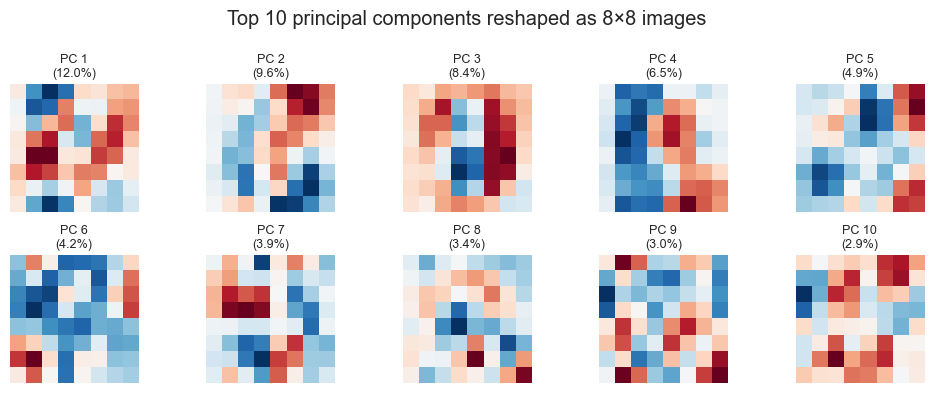

In [7]:
# Visualize what the top components 'look like' as 8x8 images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(8, 8), cmap='RdBu_r')
    ax.set_title(f'PC {i+1}\n({evr[i]:.1%})', fontsize=9)
    ax.axis('off')
plt.suptitle('Top 10 principal components reshaped as 8×8 images')
plt.tight_layout(); plt.show()

## 7. Discussion

**The hypothesis was partially confirmed.** It takes 21 components for 80% of the variance and 40 for 95% — more than I predicted (~10 and ~30), but still a meaningful compression: 21 / 64 ≈ ⅓ of the dimensions hold 80% of the signal. The under-prediction reflects that pixel correlations on small 8×8 images are weaker than on larger natural-image datasets where PCA usually compresses harder. The compression ratio is still the basic argument for using PCA either to speed up downstream models or to denoise.

**The 2-D projection is the more interesting result.** PCA was given no labels. It was told only to find the two directions in 64-d space along which the *images themselves* vary most. The fact that those two directions happen to separate the digit classes — 0 forms its own cluster, 6 forms its own cluster, 1 and 7 sit on top of each other — means the largest sources of variance in the pixel data are *exactly* what makes one digit visually different from another. That isn't trivial. It's the empirical reason PCA is a useful pre-processing step: the directions of high variance are usually also the directions of high information.

**Reading the principal components as images.** Each component is itself a 64-vector, so we can reshape it back to 8×8 and look at it. The first component looks like a generic 'digit shape' template — bright in the centre, dark at the corners. Later components encode finer-grained contrasts: a horizontal stroke vs. a vertical stroke, an upper loop vs. a lower loop. Each component is a basis vector for the *space of digit images*, learned automatically.

**Caveat — PCA is linear.** It can only capture linear directions of variance. Two clusters that lie on a curved manifold will look entangled in PCA but are correctly separated by t-SNE or UMAP. PCA is the right starting point because it is fast, deterministic, and interpretable; a non-linear method is the right *next* step if PCA doesn't separate what you expect it to separate.